In [1]:
import os
import pandas as pd
print("Files Generated:\n")

for file in os.listdir("../data"):
    print(file)

Files Generated:

assignments.csv
attendance.csv
engagement.csv
mock_tests.csv
quiz_attempts.csv
students.csv
video_logs.csv


# 1. Load Data
We load all the generated CSV files into Pandas DataFrames for analysis.

In [2]:
students = pd.read_csv("../data/students.csv")
attendance = pd.read_csv("../data/attendance.csv")
video = pd.read_csv("../data/video_logs.csv")
quiz = pd.read_csv("../data/quiz_attempts.csv")
mock = pd.read_csv("../data/mock_tests.csv")
assignment = pd.read_csv("../data/assignments.csv")
engagement = pd.read_csv("../data/engagement.csv")

# 2. Basic Inspection
We inspect the first few rows of the datasets, check their data types, summary statistics, and look for any missing values.

In [3]:
students.head()

,Student_ID,Student_Name,Class,Board,Target_Exam,Medium,Admission_Date,Study_Mode
0,STU0001,Dhruv Sarraf,Class 9,CBSE,Foundation,Tamil,2025-09-30,Online
1,STU0002,Arya Ratta,Class 10,CBSE,Foundation,English,2025-09-25,Hybrid
2,STU0003,Chameli Saraf,Class 9,State Board,NEET,English,2025-04-23,Online
3,STU0004,Neelima Sha,Class 9,CBSE,JEE,Hindi,2025-12-29,Hybrid
4,STU0005,Anamika Murty,Class 9,State Board,JEE,Hindi,2024-10-12,Hybrid


In [4]:
attendance.head()

,Student_ID,Lecture_ID,Subject,Chapter,Faculty,Lecture_Date,Attendance_Percentage
0,STU0001,LEC0001,Physics,Electricity,Dr. Ravi,2026-02-12,57
1,STU0001,LEC0002,Physics,Motion,Dr. Kumar,2026-02-21,74
2,STU0001,LEC0003,Mathematics,Algebra,Dr. Priya,2026-03-13,53
3,STU0001,LEC0004,Biology,Cell,Dr. Arun,2026-06-11,89
4,STU0001,LEC0005,Biology,Cell,Dr. Kumar,2026-02-05,93


In [5]:
attendance.head()

,Student_ID,Lecture_ID,Subject,Chapter,Faculty,Lecture_Date,Attendance_Percentage
0,STU0001,LEC0001,Physics,Electricity,Dr. Ravi,2026-02-12,57
1,STU0001,LEC0002,Physics,Motion,Dr. Kumar,2026-02-21,74
2,STU0001,LEC0003,Mathematics,Algebra,Dr. Priya,2026-03-13,53
3,STU0001,LEC0004,Biology,Cell,Dr. Arun,2026-06-11,89
4,STU0001,LEC0005,Biology,Cell,Dr. Kumar,2026-02-05,93


In [6]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Student_ID      2000 non-null   object
 1   Student_Name    2000 non-null   object
 2   Class           2000 non-null   object
 3   Board           2000 non-null   object
 4   Target_Exam     2000 non-null   object
 5   Medium          2000 non-null   object
 6   Admission_Date  2000 non-null   object
 7   Study_Mode      2000 non-null   object
dtypes: object(8)
memory usage: 125.1+ KB


In [7]:
students.describe()

,Student_ID,Student_Name,Class,Board,Target_Exam,Medium,Admission_Date,Study_Mode
count,2000,2000,2000,2000,2000,2000,2000,2000
unique,2000,1995,4,3,3,3,693,3
top,STU0001,Christopher Luthra,Class 12,ICSE,Foundation,Hindi,2026-06-04,Hybrid
freq,1,2,511,698,683,716,10,682


In [8]:
students.isnull().sum()

Student_ID        0
Student_Name      0
Class             0
Board             0
Target_Exam       0
Medium            0
Admission_Date    0
Study_Mode        0
dtype: int64

In [9]:
attendance.isnull().sum()

Student_ID               0
Lecture_ID               0
Subject                  0
Chapter                  0
Faculty                  0
Lecture_Date             0
Attendance_Percentage    0
dtype: int64

In [10]:
video.isnull().sum()

Student_ID              0
Video_ID                0
Subject                 0
Chapter                 0
Video_Length            0
Watch_Time              0
Percentage_Completed    0
Number_of_Replays       0
Completion_Status       0
dtype: int64

# 3. Data Cleaning
We remove any duplicate records from our datasets to ensure data quality.

In [11]:
students.drop_duplicates(inplace=True)

attendance.drop_duplicates(inplace=True)

video.drop_duplicates(inplace=True)

quiz.drop_duplicates(inplace=True)

mock.drop_duplicates(inplace=True)

assignment.drop_duplicates(inplace=True)

engagement.drop_duplicates(inplace=True)

# 4. Data Integration
We merge the student demographic data with their engagement metrics to create a unified view.

In [12]:
student_summary = students.merge(
    engagement,
    on="Student_ID",
    how="left"
)

student_summary.head()

,Student_ID,Student_Name,Class,Board,Target_Exam,Medium,Admission_Date,Study_Mode,Login_Frequency,Weekly_Study_Hours,Average_Session_Duration,Consecutive_Study_Days,Sessions_Per_Week
0,STU0001,Dhruv Sarraf,Class 9,CBSE,Foundation,Tamil,2025-09-30,Online,18,16.3,35,6,4
1,STU0002,Arya Ratta,Class 10,CBSE,Foundation,English,2025-09-25,Hybrid,14,23.5,52,7,9
2,STU0003,Chameli Saraf,Class 9,State Board,NEET,English,2025-04-23,Online,16,9.7,69,25,4
3,STU0004,Neelima Sha,Class 9,CBSE,JEE,Hindi,2025-12-29,Hybrid,13,19.8,169,17,2
4,STU0005,Anamika Murty,Class 9,State Board,JEE,Hindi,2024-10-12,Hybrid,20,14.3,144,7,4


# 5. Data Visualization
We plot histograms to visualize the distribution of attendance, quiz accuracy, weekly study hours, mock test marks, and assignment scores.

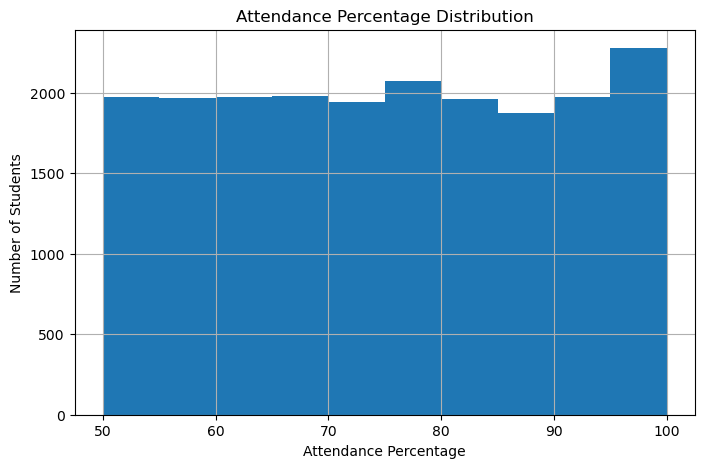

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

attendance["Attendance_Percentage"].hist(bins=10)

plt.title("Attendance Percentage Distribution")
plt.xlabel("Attendance Percentage")
plt.ylabel("Number of Students")
plt.show()

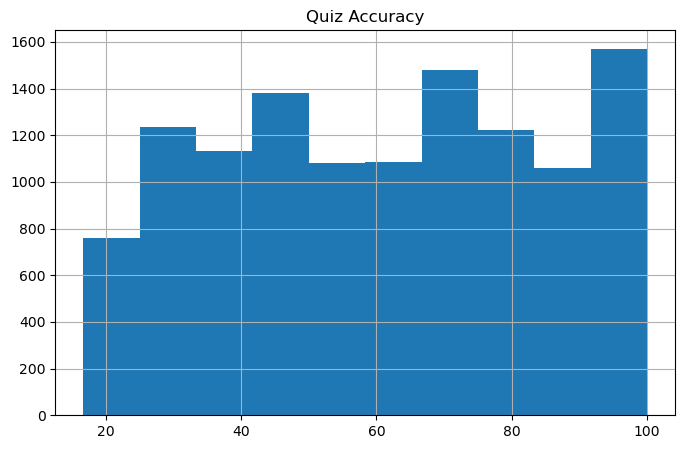

In [14]:
plt.figure(figsize=(8,5))

quiz["Accuracy"].hist(bins=10)

plt.title("Quiz Accuracy")

plt.show()

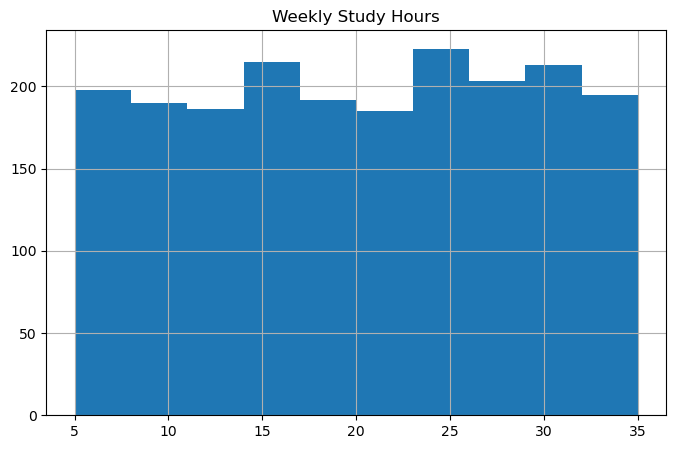

In [15]:
plt.figure(figsize=(8,5))

engagement["Weekly_Study_Hours"].hist(bins=10)

plt.title("Weekly Study Hours")

plt.show()

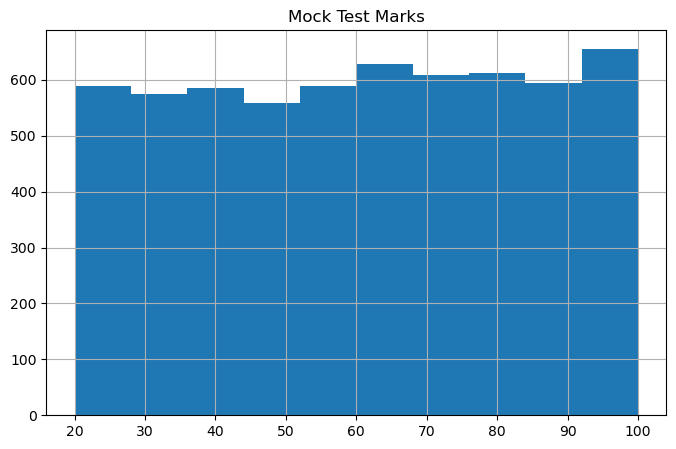

In [16]:
plt.figure(figsize=(8,5))

mock["Marks"].hist(bins=10)

plt.title("Mock Test Marks")

plt.show()

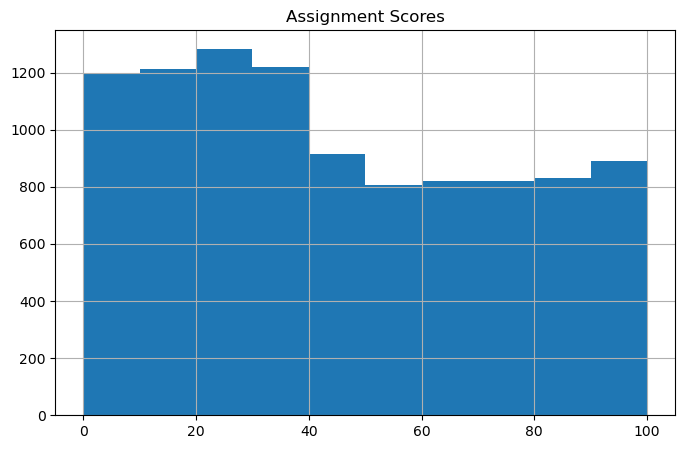

In [17]:
plt.figure(figsize=(8,5))

assignment["Score"].hist(bins=10)

plt.title("Assignment Scores")

plt.show()

# 6. Performance & Risk Analysis
We calculate average metrics per student and define a risk level based on their attendance and marks. Students are categorized as 'High Performer', 'Average', or 'At Risk'.

In [18]:
attendance_avg = attendance.groupby("Student_ID")["Attendance_Percentage"].mean().reset_index()

quiz_avg = quiz.groupby("Student_ID")["Accuracy"].mean().reset_index()

mock_avg = mock.groupby("Student_ID")["Marks"].mean().reset_index()

In [19]:
risk = attendance_avg.merge(quiz_avg, on="Student_ID")

risk = risk.merge(mock_avg, on="Student_ID")

In [20]:
def risk_level(row):

    if row["Attendance_Percentage"] < 70 or row["Marks"] < 40:
        return "At Risk"

    elif row["Marks"] >= 80:
        return "High Performer"

    else:
        return "Average"

risk["Performance"] = risk.apply(risk_level, axis=1)

In [21]:
risk.head()

,Student_ID,Attendance_Percentage,Accuracy,Marks,Performance
0,STU0001,80.8,37.736667,69.333333,Average
1,STU0002,67.4,61.533333,83.000000,At Risk
2,STU0003,71.1,67.313333,71.000000,Average
3,STU0004,66.7,82.231667,60.666667,At Risk
4,STU0005,81.7,64.335000,38.666667,At Risk
